## Prediction Analysis

We will analyze some of the predictions made by the best model over the validation set. Let's take some random element from the validation set as an example.

In [1]:
# -*- coding: utf-8 -*-
import logging
from pathlib import Path
import os
import pandas as pd
import numpy as np

import keras
from tensorflow import keras
from keras.layers import Dense
from keras.optimizers import SGD
from keras.layers import Conv1D
from keras.layers import MaxPooling1D
from keras.layers import Flatten
import statistics


In [2]:
pd.set_option("display.max_colwidth", None)


project_dir =  Path(globals()['_dh'][0]).parent
valid_csv_path = os.path.join(project_dir, r'data\processed\valid_set.csv')
valid_set = pd.read_csv (valid_csv_path)
valid_set

,filename,classID
0,wd\SDSSJ122257.58+300242.6_15249-59265-0059_4601920409.dat,WDA
1,wd\SDSSJ012606.08+144045.9_15010-59199-0313_4401110588.dat,WDA
2,wd\SDSSJ090803.30+513632.7_15174-59232-0014_4360830340.dat,WDZ
3,wd\SDSSJ015221.11-003037.7_15013-59165-0159_4375865746.dat,WDA
4,wd\SDSSJ084824.88+020918.5_15146-59206-0321_4545149860.dat,WDA
...,...,...
1118,wd\SDSSJ083628.20+354649.6_15062-59227-0336_4555706551.dat,WDA
1119,wd\SDSSJ063256.89+171629.5_15229-59303-0400_4537378243.dat,WDA
1120,wd\SDSSJ164122.52+393649.2_15309-59312-0293_5191881977.dat,WDA
1121,wd\SDSSJ075645.52+272747.8_15021-59165-0078_4554384693.dat,WDA


In [3]:
filename = valid_set.sample(random_state=1)['filename'].to_string()
tid = filename.split('_')[-1][:-4]

In [4]:
print(filename, '\n',  tid)

479    wd\SDSSJ143122.16+094849.9_15202-59250-0156_4601006722.dat 
 4601006722


Now let's look at the tags that the different observations of the object have

In [5]:
clabels_csv_path = os.path.join(project_dir, r'data\interim\clean_labels.csv')
clean_labels = pd.read_csv (clabels_csv_path)


object_obs = clean_labels[clean_labels['Target ID'] == int(tid)]
object_obs

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
2146,WDA,20803,OK,spec-15202-59250-04601006722-20803.png,59250,4601006722
6431,WDA,20803,OK,spec-15202-59324-04601006722-20803.png,59324,4601006722
17357,WDA,20803,FC,spec-15202-59250-04601006722-20803.png,59250,4601006722
27302,WDA,20803,OK,spec-15202-59250-04601006722-20803.png,59250,4601006722
33226,WDA,20803,OK,spec-15202-59276-04601006722-20803.png,59276,4601006722


In [6]:
sdss_datfiles_path = os.path.join(project_dir, r'data\raw\sdss_dat_files')

folder_list = os.listdir(sdss_datfiles_path)
file_dict = dict()
for folder in folder_list:
    file_list = os.listdir(os.path.join(sdss_datfiles_path, folder))
    for filename in file_list:
        if filename.endswith('.dat'):
            file_dict[filename.split('-')[-2] + '_' + filename.split('_')[-1]] = os.path.join(folder, filename)

dat_files = []

for _, row in object_obs.iterrows():
    filekey = str(row['MJD']) + '_' + str(row['Target ID']) + '.dat'
    if filekey in file_dict:
        dat_files.append(file_dict[filekey])


In [7]:
dat_files = list(set(dat_files))
dat_files

['wd\\SDSSJ143122.16+094849.9_15202-59250-0156_4601006722.dat',
 'wd\\SDSSJ143122.16+094849.9_15202-59324-0266_4601006722.dat',
 'wd\\SDSSJ143122.16+094849.9_15202-59276-0250_4601006722.dat']

In [8]:
# for remote work purpose only
# project_dir =  Path(globals()['_dh'][0]).parent
# dat_files = ['wd\\SDSSJ143122.16+094849.9_15202-59250-0156_4601006722.dat',
#  'wd\\SDSSJ143122.16+094849.9_15202-59324-0266_4601006722.dat',
#  'wd\\SDSSJ143122.16+094849.9_15202-59276-0250_4601006722.dat']

Let's see what the prediction on one dat file looks like.

In [9]:
import sys
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../src'))
import src.models.predict_model as pmdl

In [10]:
best_model_path = os.path.join(project_dir, r'models\best_model_all_data.h5')
dom_model_path = os.path.join(project_dir, r'models\rf_dom_v1.joblib')
dat_file_folder= os.path.join(project_dir, r'data\raw\sdss_dat_files')


wd_model = pmdl.wd_predictor(model_path=best_model_path, dom_path=dom_model_path, dat_file_path=dat_file_folder)

In [11]:
results = []
results_dom = []
for file in dat_files:
    results.append(wd_model.predict_class(file))
    #results_dom.append(wd_model.predict_dom(file))

c:\Users\mafalsa\OneDrive - Universidad Técnica Federico Santa María\Documentos\GitHub\ML_NPF\data\raw\sdss_dat_files\wd\SDSSJ143122.16+094849.9_15202-59250-0156_4601006722.dat
1/1 [==============================] - 0s 178ms/step
c:\Users\mafalsa\OneDrive - Universidad Técnica Federico Santa María\Documentos\GitHub\ML_NPF\data\raw\sdss_dat_files\wd\SDSSJ143122.16+094849.9_15202-59324-0266_4601006722.dat
1/1 [==============================] - 0s 66ms/step
c:\Users\mafalsa\OneDrive - Universidad Técnica Federico Santa María\Documentos\GitHub\ML_NPF\data\raw\sdss_dat_files\wd\SDSSJ143122.16+094849.9_15202-59276-0250_4601006722.dat
1/1 [==============================] - 0s 68ms/step


In [12]:
import src.visualization.visualize as vsz

train_label_matrix = np.load(os.path.join(project_dir, r'data\processed\lpv1_train_label_matrix.npy'))
train_csv_path = os.path.join(project_dir, r'data\processed\train_set.csv')
train_set = pd.read_csv (train_csv_path)
ohe_dict = vsz.ohe_decoder(train_set['classID'], train_label_matrix)
star_class = vsz.sort_ohe(ohe_dict)
ohe_dict

{'WDA': array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WDZ': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]),
 'WDB': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]),
 'WDO': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]),
 'WD+MS': array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WD': array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'sdX': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 'WDH': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
 'WDELM': array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]),
 'WDC': array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]),
 'CV': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WDQ': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])}

In [13]:
# For remote work purposes only:

# ohe_dict = {'WDA': np.array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]),
#  'WDZ': np.array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]),
#  'WDB': np.array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]),
#  'WDO': np.array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]),
#  'WD+MS': np.array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
#  'WD': np.array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
#  'sdX': np.array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
#  'WDH': np.array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
# 'WDELM': np.array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]),
#  'WDC': np.array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]),
#  'CV': np.array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
#  'WDQ': np.array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])}

# star_class = vsz.sort_ohe(ohe_dict)
# star_class

In [14]:
import matplotlib.pyplot as plt

([<matplotlib.axis.XTick at 0x24849c8ec70>,
 [Text(0, 0, 'CV'),
  Text(1, 0, 'WD'),
  Text(2, 0, 'WD+MS'),
  Text(3, 0, 'WDA'),
  Text(4, 0, 'WDB'),
  Text(5, 0, 'WDC'),
  Text(6, 0, 'WDELM'),
  Text(7, 0, 'WDH'),
  Text(8, 0, 'WDO'),
  Text(9, 0, 'WDQ'),
  Text(10, 0, 'WDZ'),
  Text(11, 0, 'sdX')])

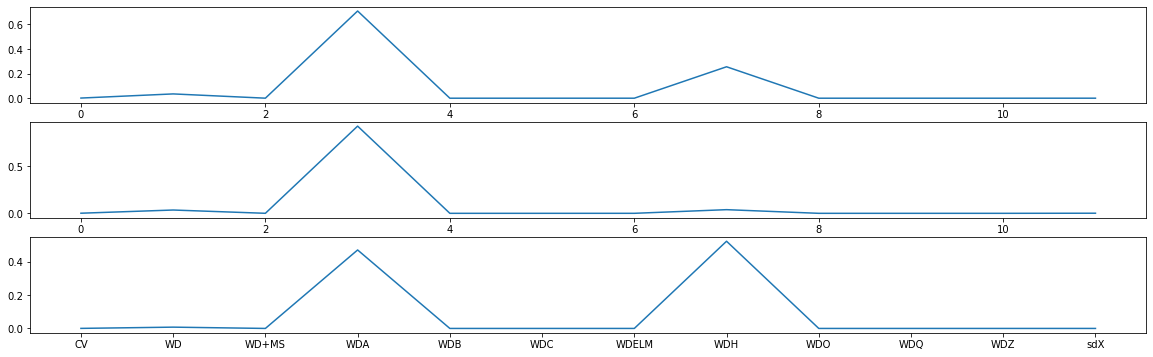

In [15]:
fig, ax = plt.subplots(nrows = len(results),figsize=(20,6))
x = range(12)
for index, result in enumerate(results):
    ax[index].plot(x, results[index])
plt.xticks(x, labels=star_class)

In [16]:
x

range(0, 12)